# Importing Related Packages

In [76]:
import pandas as pd
from pandas.plotting import scatter_matrix
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector, make_column_transformer
import sklearn
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
import matplotlib
from matplotlib import pyplot
import numpy as np

# Loading/Reading Data

In this section we are trying to load the local or ready to go libraries data.

Right now we have an ready to go dataset for this sample, but if didn't have that we could use the _skilearn_ ready to go datasets

Our local dataset:

In [4]:
housing = pd.read_csv("../datasets/housing.csv")

Our sklearn ready to go dataset

In [5]:
import sklearn

# Wine dataset
wine_dataset = sklearn.datasets.load_wine()
digit_dataset = sklearn.datasets.load_digits()


# Showing data summery

We are trying to show the data to see the each item and it's value

In [6]:
housing.head() # Returning top 5 items from the 'housing.csv' dataset

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


We can have a better look at the data and its _type_ or how much _non-null values_ do we have inside each column with this code:

In [7]:
housing.info() # Return overall info about dataset items

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [8]:
print(housing["ocean_proximity"]) # The Original Data
housing["ocean_proximity"].value_counts() # With Special Information

0        NEAR BAY
1        NEAR BAY
2        NEAR BAY
3        NEAR BAY
4        NEAR BAY
           ...   
20635      INLAND
20636      INLAND
20637      INLAND
20638      INLAND
20639      INLAND
Name: ocean_proximity, Length: 20640, dtype: str


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

As what we can see, the _<1H OCEAN_ has more values than other fields, and the counter for it has *int64* value

In [9]:
housing.describe() # Show overall information about each coulmn

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


__Notice__: This shows all the data related to each column. This is not just for 1 column as we can do that with ```info``` function.

# Histogram

we can have a visual representation of our data using histograms

we use histogram to see the توضیع داده ها 

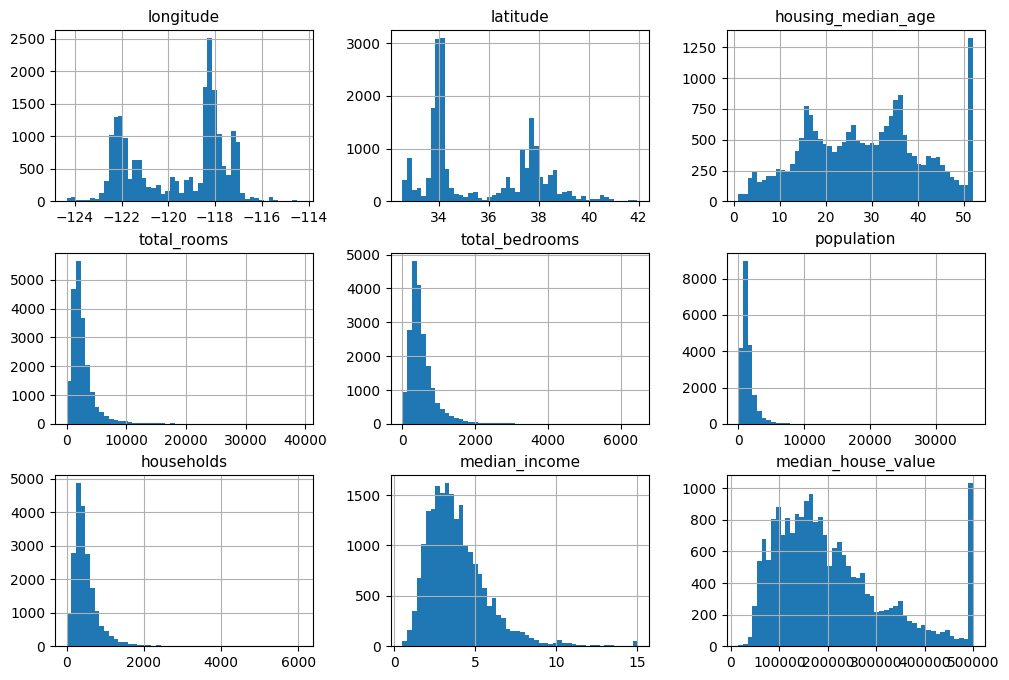

In [10]:
# housing.hist()

matplotlib.pyplot.rc("font", size=9)
matplotlib.pyplot.rc("axes", labelsize=14, titlesize=11)
matplotlib.pyplot.rc("legend", fontsize=14)
matplotlib.pyplot.rc("xtick", labelsize=10)
matplotlib.pyplot.rc("ytick", labelsize=10)

housing.hist(bins=50, figsize=(12, 8))

matplotlib.pyplot.show()

As you can see, the X represents the actual values inside each field. for example the __median_income__ field has much more 0 to 5 values (0.0 -> 5.0 in float) than other values.


For checking if this is true you can use your custom tool to process the file manually, I used _bash_ for this:


```bash
#!/bin/env bash

count=0

for i in {1..15}; do
  echo "For $i. we have:"
  cat ./output.txt | grep -F "$i." | wc -l
  echo ""
done
```

running this gives us this output:



```
For 1. we have:
2329

For 2. we have:
4960

For 3. we have:
5173

For 4. we have:
3621

For 5. we have:
2187

For 6. we have:
1174

For 7. we have:
508

For 8. we have:
284

For 9. we have:
98

For 10. we have:
151

For 11. we have:
45

For 12. we have:
34

For 13. we have:
22

For 14. we have:
6

For 15. we have:
51
```

This means there is more _'3.'_ than other values.

one of the things that we have to concider is that the _maximum_ number for _X_ row is not the maximum number that we want our model _support_. This means we have to tell the model this is not your limit and you should be able to process even more than this number.


__Notice__: Histograms that has __Bell Shape__ are better to work with, then maybe we will __Transform__ it to that shape


# Test Set

Before doing any other process, we have to choose some of our data from dataset (housing.csv) to be our _test set_. we often choose 20% of the original data for that. then test set is:

_The test set is a portion (or partition) of the available training data that is “held back” and not used during model training. The purpose of the test set is to evaluate the performance of the model on unseen data after it has been trained._

Using _test set_ we can evaluate the generatization number (میزان تعمیم پذیری).

In [11]:
from sklearn.model_selection import train_test_split

random_train_set, random_test_set = train_test_split(housing, test_size=0.2, random_state=42) # Splitint data into 2 parts by 20% (0.2) for test_case data & a random number 42

random_test_set.info()
random_test_set.head()

<class 'pandas.DataFrame'>
Index: 4128 entries, 20046 to 3665
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           4128 non-null   float64
 1   latitude            4128 non-null   float64
 2   housing_median_age  4128 non-null   float64
 3   total_rooms         4128 non-null   float64
 4   total_bedrooms      4084 non-null   float64
 5   population          4128 non-null   float64
 6   households          4128 non-null   float64
 7   median_income       4128 non-null   float64
 8   median_house_value  4128 non-null   float64
 9   ocean_proximity     4128 non-null   str    
dtypes: float64(9), str(1)
memory usage: 354.8 KB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20046,-122.38,40.67,10.0,2281.0,444.0,1274.0,438.0,2.2120,65600.0,INLAND
3024,-118.37,33.83,35.0,1207.0,207.0,601.0,213.0,4.7308,353400.0,<1H OCEAN
15663,-117.24,32.72,39.0,3089.0,431.0,1175.0,432.0,7.5925,466700.0,NEAR OCEAN
20484,-118.44,34.05,18.0,4780.0,1192.0,1886.0,1036.0,4.4674,500001.0,<1H OCEAN
9814,-118.44,34.18,33.0,2127.0,414.0,1056.0,391.0,4.3750,286100.0,<1H OCEAN


And here is our _test set_ histogram

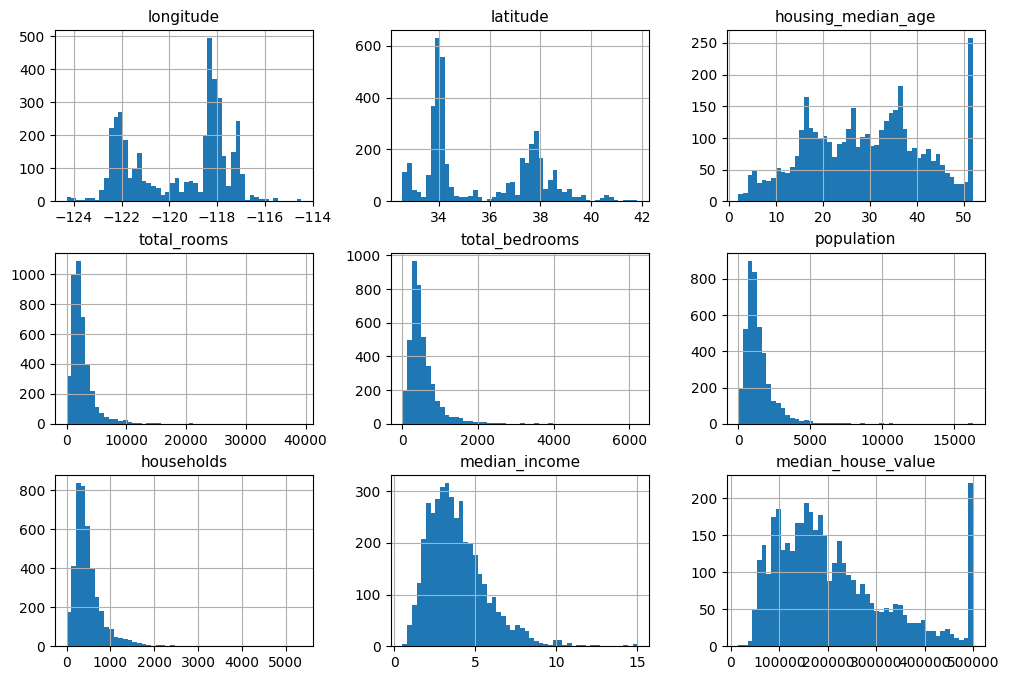

In [12]:
random_test_set.hist(bins=50, figsize=(12, 8))

matplotlib.pyplot.show()

## Random Sampling
_Random Sampling_ works best when we have big data, but for smaller data we may encounter the _Sampling Bias_ problem, that means the ratio of our test_set data is not equal to the ratio of our train_set data. this leads to problems like:

- The output model dones't work for real-world scenarios

<br>

For fixing this, we have to use better ways and smarter mechanism, such as _stratified sampling_

## Snooping Bias
Snooping bias happens when information from the test set leaks into training. This makes test performance look good, but the model fails on real unseen data.

## Stratified Sampling
__Note__: First, for doing this mechanism we have to check our data type, if it is _continuous_ we should convert it to _discrete_ data.

For doing this, we are going to categorize our __median_income__ feature into 5 groups, we do this on the most __heavy__ side of our data. The range of 0 to 6 is a good idea because there is much more data in this range than other ones. look at the [Histogram](#Histogram) for more information.

__Notice__: When you do ```.info()``` on your test_set for random_sampling or stratified sampling, you will get the same amount of non-null data. This shows nothing! because we are not talking about _"How much data we splitted"_ both of them will split rophly the same size (sometimes stratifing may differ to random sampling in the case of the amount of data splitting) and when do the info function it's clear that we did the 20% splitting called test_set. But the real change is happening inside those data. Let's explain with this example:

Imagine you have a giant wardrobe with 100 items of clothing: 80% are socks and 20% are expensive suits. You need to pack a suitcase with 10 items.

    Random Sampling: You reach in blindfolded and grab 10 items. You might end up with 10 socks and 0 suits.
    Stratified Sampling: You look first, and you make sure to grab exactly 8 socks and 2 suits so your suitcase looks exactly like your wardrobe.

In both cases, .info() on your suitcase would say: Items: 10.

The size is the same, but the representative quality of the contents is vastly different.

This means we want to most important data splitted with the same amount of composition. __The data itself is important, not the count of it__


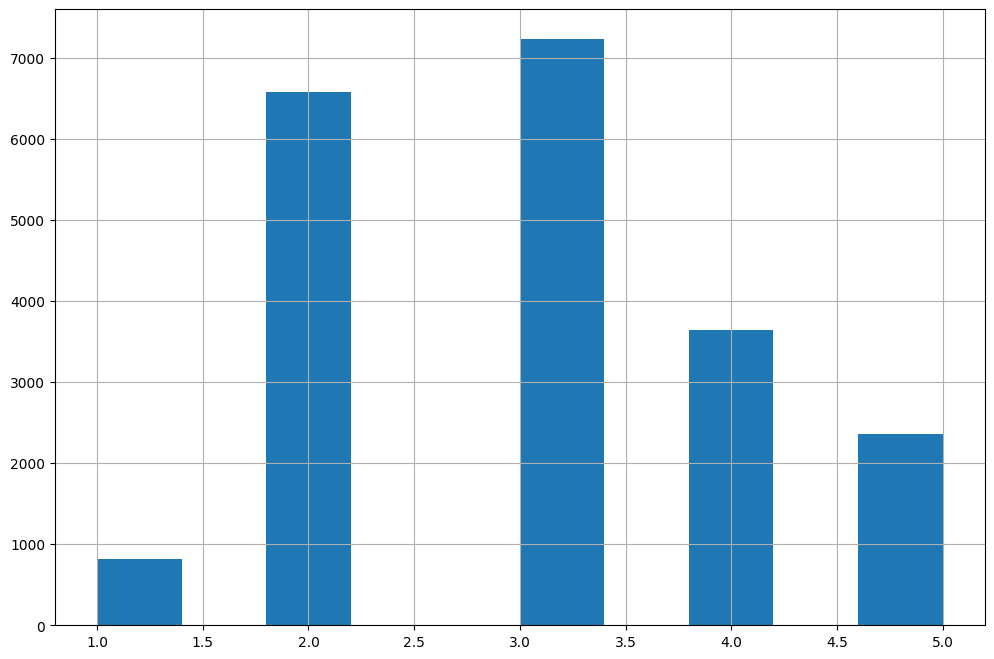

In [13]:
housing["median_cat"] = pd.cut(housing["median_income"], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5]) # Categorize 'median_income' data into 5 categories.

# Showting the result using _Histogram_ (we configed it before on above lines)
housing["median_cat"].hist(bins=10, figsize=(12, 8))
matplotlib.pyplot.show()

Now by doing this, we have 5 _discrete data_ and the median_income data is no longer _continiues_.

For spliting our data ([Stratified Spliting](#stratified_sampling)) we can use the _skilearn.model_selection_ library module with few functions that it gives us. For example we did the ```train_test_split``` function before to see how it works. But for doing _stratified sampling_ we have to provide our new category that we made (median_cat) for it:

<class 'pandas.DataFrame'>
Index: 4128 entries, 3905 to 3455
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           4128 non-null   float64 
 1   latitude            4128 non-null   float64 
 2   housing_median_age  4128 non-null   float64 
 3   total_rooms         4128 non-null   float64 
 4   total_bedrooms      4089 non-null   float64 
 5   population          4128 non-null   float64 
 6   households          4128 non-null   float64 
 7   median_income       4128 non-null   float64 
 8   median_house_value  4128 non-null   float64 
 9   ocean_proximity     4128 non-null   str     
 10  median_cat          4128 non-null   category
dtypes: category(1), float64(9), str(1)
memory usage: 358.8 KB


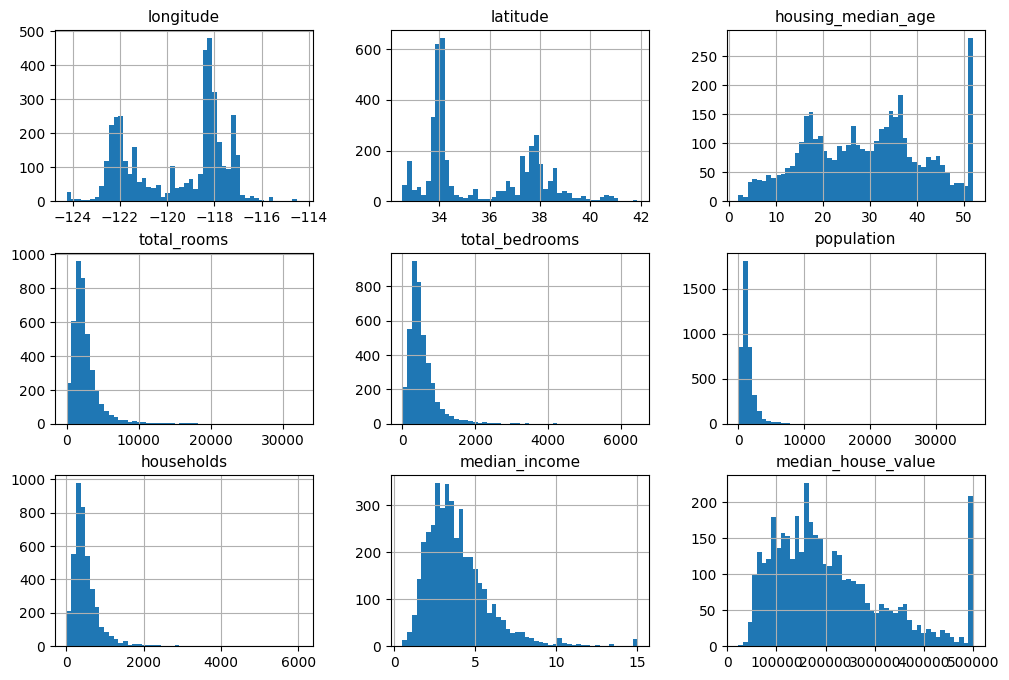

In [14]:
strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2, stratify=housing["median_cat"], random_state=42) # Spliting our data with stratify mechanism

strat_test_set.info() # As you can see both 'random sampling' and 'strat sampling' is showsing almost the same output with this function.
strat_test_set.head()
strat_test_set.describe()

# strat_test_set.hist(bins=50, figsize=(12, 8))
strat_test_set.hist(bins=50, figsize=(12, 8))
matplotlib.pyplot.show()

But you may ask "__How can we see the difference between stratifing sampling and random sampling ?__" The answer is doing this code:

In [15]:
random_test_set["median_cat"] = pd.cut(housing["median_income"], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5]) # Categorize 'median_income' data into 5 categories.

compare = pd.DataFrame({
    "Overall": housing["median_cat"].value_counts(normalize=True) * 100,
    "Stratified": strat_test_set["median_cat"].value_counts(normalize=True) * 100,
    "Random": random_test_set["median_cat"].value_counts(normalize=True) * 100
}).round(2)

compare["Stratified_error"] = compare["Stratified"] - compare["Overall"]
compare["Random_error"] = compare["Random"] - compare["Overall"]

print(compare.sort_values(by="median_cat", ascending=True))

            Overall  Stratified  Random  Stratified_error  Random_error
median_cat                                                             
1              3.98        4.00    4.24              0.02          0.26
2             31.88       31.88   30.74              0.00         -1.14
3             35.06       35.05   34.52             -0.01         -0.54
4             17.63       17.64   18.41              0.01          0.78
5             11.44       11.43   12.09             -0.01          0.65



After processing the and splitting our data into _train_set_ and _test_set_ then we should remove the _median_cat_ feature to return to our needed state.

In [16]:
housing.drop("median_cat", axis=1, inplace=True) # In case if we have the it

# Important steps before training

- we have to be sure that our _test_set_ is not a part of our _train_set_ anymore. for that we can run a simple info and check the amount of value that we have on _median_income_.

In [17]:
strat_train_set.info()
strat_test_set.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16512 non-null  float64 
 1   latitude            16512 non-null  float64 
 2   housing_median_age  16512 non-null  float64 
 3   total_rooms         16512 non-null  float64 
 4   total_bedrooms      16344 non-null  float64 
 5   population          16512 non-null  float64 
 6   households          16512 non-null  float64 
 7   median_income       16512 non-null  float64 
 8   median_house_value  16512 non-null  float64 
 9   ocean_proximity     16512 non-null  str     
 10  median_cat          16512 non-null  category
dtypes: category(1), float64(9), str(1)
memory usage: 1.4 MB
<class 'pandas.DataFrame'>
Index: 4128 entries, 3905 to 3455
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----  

As you can see we did the splitting part very well! and thanks to stratring mechanism (function) _median_income_ that is very important and effects our overall output got splitted carefully with other features.

now that we have all the thing that we need, we can make a copy of our train_set then anytime we want to rewind something we can use this copy.

In [18]:
housing = strat_train_set.copy() # shadowing our housing variable with our 80% train_set

# Data Illustration
Well because we have features like _longitude_ & _latitude_we can illustrate our train data (housing) using pandas ```.plot()``` function.

There is some option here that we are going to use:

- s: the size of each point based on the value of population (devided with 100 for better rendering)
- label (after s): prints a text with the alias color of __c__ argument maximum value (often red).
- c: the feature that we used here to show the density of houses values by using color (we are using _jet_ color pallet here)
- cmap: setting a per-defined color pallet called _jet_ (from blue to red by value based on feature value)
- colorbar: showing color bar optino
- legend: -
- sharex: -
- figsize: overall size of the histogram.

__Note:__ we add ```alpha=0.2``` to represent density of multi dots.

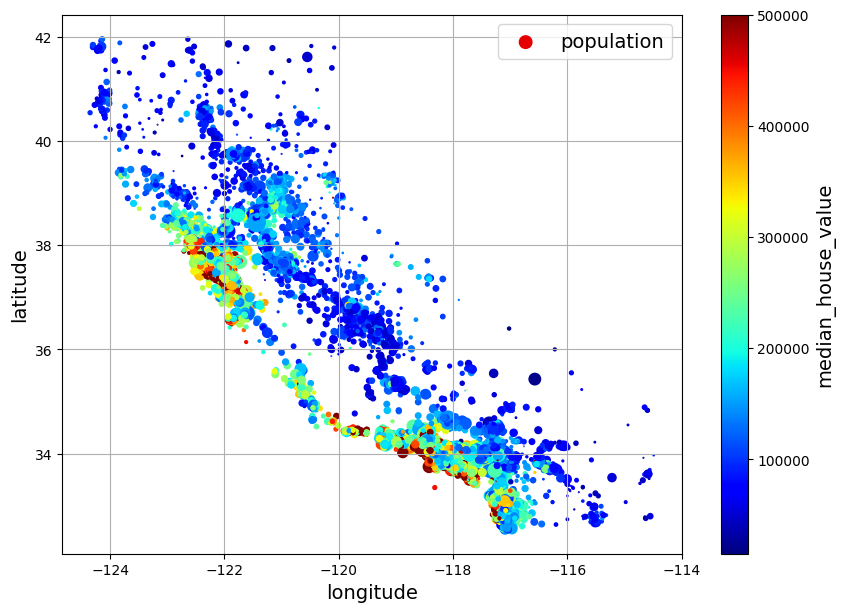

In [19]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, s=housing["population"] / 100, label="population", c="median_house_value", cmap="jet", colorbar=True, legend=True, sharex=False, figsize=(10, 7))
matplotlib.pyplot.show()

# Standard Correlation Coefficient
We do _Correlation Coefficient_ also known as Pearson) between 2 dots. we do this to find out how much their relationship is strong and it is positive or negative or even 0 (or 0.1 means no relationship)

It's important that pearson only works when we have __linear__ data, even a __U__ shape data will not produce any true answer (often 0.0)

Then this means:

Pearson correlation is based on two things:

    How much X and Y vary away from their means
    Whether they tend to vary in the same direction or opposite directions

If both go above/below their means together → positive correlation
If one goes up when the other goes down → negative correlation
If there is no consistent joint movement → correlation near zero

we can think of like this:

    When X increases, does Y also increase?
    When X increases, does Y decrease?
    Do they move independently?

## Example

If correlation between median_income and median_house_value is +0.69:

    They have a strong positive linear relationship
    Higher-income neighborhoods tend to have higher-priced houses
    Income is a powerful predictor
    Stratifying by income helps maintain data structure (our earlier discussion!)

You may ask, then how can we do it with code? well that's my job to tell you that! <3



In [20]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

As you can see, we can see the relationship between _median_house_value_ and other features. the funny point is that the _median_house_value_ itself has the result value of ```1.0``` with itself. This means that when you compare something with itself it always ends up as itself.

The most strong feature that we found is _median_income_. This feature has +0.6 that means by increasing the median_income we will see the increase of median_house_value too.

# Pandas Scatter Matrix
It is a grid of dots showing pairwise relationship between several numerical features.

## Why we use it
- Because it lets you see relationships visually.
- Correlation gives you one number.
- Scatter matrix gives you the shape of the relationship.
- That is a huge difference.

The main reason why we do this after doing _Correlation_ is, ـPearson_ only shows numerical pairwise relationship between features (that is 1,0,-1) that's it! but _Scatter_ shows the actuall illustration of them and if there is not any _Pearson_ relationship (corre = 0.0) then this visualization can find other type of relationship if available inside them.

Then using _Scatter_ to find correlations, we have these advantages over _Pearson_ mechanism:

- one may be random noise
- another may form a curve
- another may have two clusters
- another may have one huge outlier destroying the correlation

Then we can say this for conclution:

Correlation = compressed summary

Scatter matrix = raw visual evidence

For using this inside the project we can use pandas libraries to do _Scatter Matrix_

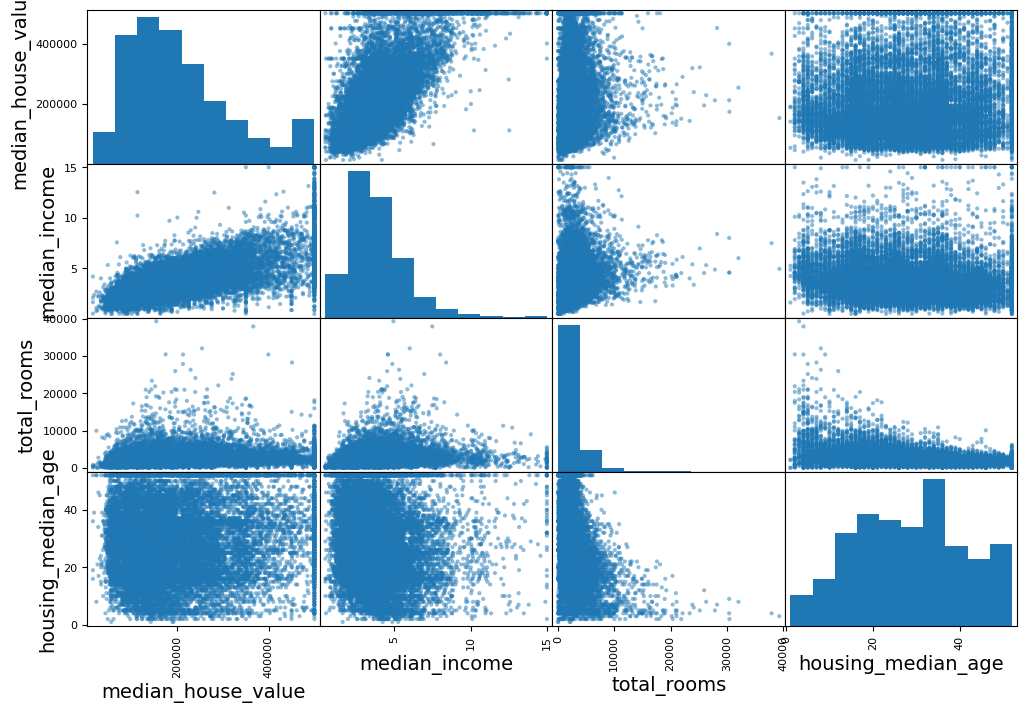

In [21]:
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]

scatter_matrix(housing[attributes], figsize=(12, 8))
matplotlib.pyplot.show()

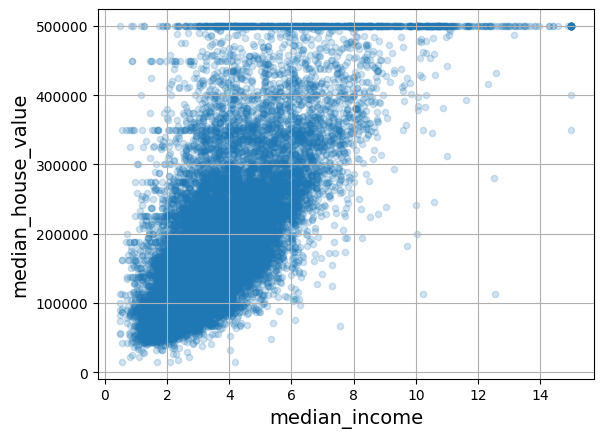

In [22]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.2, grid=True)
matplotlib.pyplot.show()

This Clearly shows the strong linear relationship between _median_income_ and _median_house_value_

# Attribute Combination (Feature Engineering)

It's the art of combining raw features (raw features means features that they don't present valuable data by themselves) or one raw feature with one valuable feature to make something new that is more valuable then before, with more potentioal and meanings for the model.

## Example
Simple empty bedrooms of an area is not a really useful information and feature by itself, but if we could know the _bedrooms of __house_holds__ that would be more useful for our final output. This means we can combine _totla_rooms_ with _house_holds_ (that they have real-life relationship) and make something like _rooms_per_house_. By doing this mechanism we can make more useful features than before.

Take a look at this code

In [23]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = (housing["total_bedrooms"] / housing["total_rooms"]).replace([np.inf, np.inf], 0)
housing["people_per_house"] = housing["population"] / housing["households"]

In [24]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

__Notice:__ How _bedrooms_ratio_ shows a more powerful relationship that using _total_bedrooms_ or _total_rooms_ alone. It's true that the value become negative __but__ it is more close to 1 than using those alone. this means using _Feature Engineering_ we can produce more effective features.

It's a worth mentioning that _Feature Engineering_ is a __Iterative process__, this means by creating our first version of model we can return to this layer again.

# Remove Out output variable from train_set

for continue working with our train_set we have to remove our output and predict variable using this code

In [25]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_cat
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,NEAR BAY,2
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,<1H OCEAN,5
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,INLAND,2
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,INLAND,2
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,NEAR OCEAN,3
...,...,...,...,...,...,...,...,...,...,...
14207,-118.40,33.86,41.0,2237.0,597.0,938.0,523.0,4.7105,<1H OCEAN,4
13105,-119.31,36.32,23.0,2945.0,592.0,1419.0,532.0,2.5733,INLAND,2
19301,-117.06,32.59,13.0,3920.0,775.0,2814.0,760.0,4.0616,NEAR OCEAN,3
19121,-118.40,34.06,37.0,3781.0,873.0,1725.0,838.0,4.1455,<1H OCEAN,3


# Working with Null Values (Data Cleaning)

For working with our null values we have to choose a mechanism, because null values are not good for our output model.

for doing that we have these 3 options:

1. Removing All null values for a coulmn
2. Removing the coulmn itself
3. Replace All null values to 0 or the median or its column

In [26]:
# housing.dropna(subset=["total_bedrooms"], inplace=True) # Option1: Remove All Null Values
# housing.drop("total_bedrooms", axis=1) # Option2: Remove entire feature

# Options3: replacing values with the median of that coulmn
# housing_option3 = housing.copy()
# median = housing["total_bedrooms"].median() # Calculate Median
# housing_option3["total_bedrooms"] = housing_option3["total_bedrooms"].fillna(median) # Replace  Median To All null values

When we say replacing 'median' with the null rows, we actually mean this:

1. Getting the median from the __entire__ coulmn's items
2. Replacing that __1__ median number with all the _Null_ values for that coulmn.

# Simple Imputer Class

Or we can use the __SimpleImputer__ that is a better option and it does all the things by its own automaticaly. It's better because it is more __standard__ and it holds the results inside the memory.

__Note__: one more feature is that __SimpleImputer__ Class will hold all the _median_ that it calculated inside the memory. This way we can use it easily and fast in the future.

__Notce__: We are using 'median' as our strategy inside _SimpleImputer_ argument. This works because we are working with numerical values, if it was something else like strings, then
we could use something like 'most_frequency'.

In [27]:
# Printing All Null Values
null_rows_idx = housing.isnull().any(axis=1)
housing.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_cat
14452,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,INLAND,3
18217,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,<1H OCEAN,3
11889,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,<1H OCEAN,3
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,<1H OCEAN,4
14360,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,<1H OCEAN,5


In [41]:
imputer = SimpleImputer(strategy="median") # Instance the class with strategy (median, most_frequency (fill with most frequent value (great for strings)))
housing_num = housing.select_dtypes(include=[np.number]) # Take all numeric columns
imputer.fit(housing_num) # mohasebe median baraye tamam soton ha (train)
# print(imputer.statistics_) # shows the median of all columns
X = imputer.transform(housing_num) # take all housing features what is numeric numbers and replace median with related column (median from same column will be replaced by the null values from same column) (predict the output
# (median from same column will be replaced by the null values from same column) (predict the output)

In [42]:
# null_rows_idx = housing_sum.isnull().any(axis=1)
# housing_sum.loc[null_rows_idx].head()
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)
housing_tr.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020


As we can see, all _Nan_ items replaced with _434.0_ the median of _total_bedrooms_

# Converting Strings To Catogories (discrite)

Because machine learning (ML) works better with numbers, we should convert any string like columns into a discrite categories. we can do that by using OrdinalEncoding from sklearn. _OrdinalEncoding_ encodes the variant of the value of related feature with a number, like 1, 2, 3, 4.

- What is the problem with _OrdinalEncoding_?
Because it sets numbers __increasingly__ this makes the model think the ordinal number 4 has higher priority than ordinal number 1.

Or there is a better way called 'One-Hot' that says __How many string variants do we have?__
For answer that question we can do:

In [30]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     7274
INLAND        5301
NEAR OCEAN    2089
NEAR BAY      1846
ISLAND           2
Name: count, dtype: int64

It shows __5__

In [31]:
# encoder = OrdinalEncoder()
# encoded = encoder.fit_transform(housing[["ocean_proximity"]])

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing[["ocean_proximity"]])

housing_cat_1hot_df = pd.DataFrame(
    housing_cat_1hot.toarray(),
    columns=cat_encoder.get_feature_names_out(["ocean_proximity"])
)

print(housing_cat_1hot_df.head())

   ocean_proximity_<1H OCEAN  ocean_proximity_INLAND  ocean_proximity_ISLAND  \
0                        0.0                     0.0                     0.0   
1                        1.0                     0.0                     0.0   
2                        0.0                     1.0                     0.0   
3                        0.0                     1.0                     0.0   
4                        0.0                     0.0                     0.0   

   ocean_proximity_NEAR BAY  ocean_proximity_NEAR OCEAN  
0                       1.0                         0.0  
1                       0.0                         0.0  
2                       0.0                         0.0  
3                       0.0                         0.0  
4                       0.0                         1.0  


# Fit vs Transform vs Predict

sklearn has multiple functions and it has its own structure. Using _Fit_ or _Transform_ function does differenet stuff like this:

- Fit: Calculating something (like median) on the current train_set data that we have (finding parameters)
- Transition: Chaning or doing any transition in train_set data (modification) that returns changed, new data.
- Predict: Predecting a new value based on train_set data.
- Estimators: every class that 'fit' function concider a simple estimator, in statistics 'estimators' are anyhting that can predict parameters of a distribution/models.

The great news is, we can customize the Classes inside the pandas as what we need and what we want.

# Feature Scaling

## Different Input Scale

Machine learning algorthims and models have problems with input of different scales. This means if a number/value from one coulmn is much higher than the value of another coulmn (column means features) the modeel will not produce/predict a good result.

### Example
The _total_tooms_ feature has the range of 2.0 to 39_329. But the median_income feathre has the value range of 0 to 15. this means _total_rooms_ has much higher values than _median_income_ and then model will think that it should consider a higher priority for _total_rooms_ feature than _median_income_ (or any other features)

# Feature Scaling Algorithms

## Min-Max Scaling
Formula:

$$
X_{\text{normalized}} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}}
$$

it compress features into the range of [1, -1], this way all features can represent the same amount of value, then there is not any higher priority.

- Why it's not a great option? Because it's sensitive to outliers. If you have an extreme outlier, it can compress the rest of your data into a very small sub-range, making it hard to discern differences among those non-outlier points.

You can find max/min of a feature using this:

In [43]:
housing["total_rooms"].max() # The highest value inside total_rooms column
# housing["total_rooms"].min() # the lowest value inside total_rooms column

np.float64(39320.0)

In [44]:
# Using MinMax Scaling functions
min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)


To fix this, we have to use __Standardization__
## Standadization
Formula:
$$
X_{\text{standardized}} = \frac{X - \mu}{\sigma}
$$
This mechanism centers the data around zero and scales it based on its spread. It doesn’t force the data into a fixed range. Values can be greater than 1 or less than -1 (though most will be within -3 to 3 for typical distributions).

دو تا پارامتر داریم تحت عنوان 'میانگین' و 'انحراف' معیار استاندارد

In [45]:
# Using StandardScaler
std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

# Heavy-Tiled Distribution

## Power Low Distribution
There is a high peak at first, and then immidietally we see a low peak. as we said that _bell_ like shapes is a better shape for a feature, we should fix this by using related mechanisms. One of them is __Logarithm__. Using logarithm we can change the shape from a _power low distribution_ to _bell distribution_/

__Important Note__: When we __logarithm__ a feature, we are changing it, this way, if we predict something on it we will get the __logarithm__ result! becuase we did __logarithm__ on all the values on that feature to remove the power low distribution. For fixing this, we should reverse the __logarithm__ before displaying the result of _predict_ function. _Sklean_ has a function called _inverse_transform_ that does the same concept.

# Bucketizing Multi-Modal Distributions
In our tain_set data, we can find features that has multiple _Mods_ Or better to say _Peaks_. AI models work better with features that represent one peak, for fixing those _multimodal distributions_ we can do _Bucketizing_. This way we categorize peaks into seprate groups that has _Bucket ID_. __This mechanism changes/convert the continiues feature into discrete feature__.

We do bucketizing using __One-Hot Encoder__.

__Notice:__ This mechanism teaches different rules for each peak area. For example 35 years old house, because of specific architucture may be cheaper than 30 years old houses.

# Gaussians RBF
This is another way of fixing multimodal features. using this we separate each high peak (mode) into a __separate feature__. we do this by:

1. choosing peak: This should be a high peak that represents a big change in our feature
2. distance calculating: calculating the distance between another peak (for example a mode from the left of the choosed mode). we do this by subtracting $Y$ number of left peak to choosed peak, and calculate it to the power of 2, cause it may contains negative value and this way we can make it positive. (formula mentions below).
3. 


- Gaussians RBF Fomula:

$$
exp(-y(x-35)^2)
$$


__Note:__ We do this for each peak/mode that we think we need to seperate.

# Reversing Transformed output

after transforming data using scaler or logarithm, machine will learn everything based on those algorithms, because of that we have to reverse it when we _predict_ something on it, to represent the actual un-logarithm value as result (as what we need is not the logarithmed values, it is the real value).

Sklean provides a mechanism for scaling before training and reverse their output after predicting, we use it by using __TransformTargetRegressor__

In [35]:
model = TransformedTargetRegressor(LinearRegression(), transformer=StandardScaler())
model.fit(X_train, y_train) # y_train scales automatically
predictions = model.predict(X_test) # Automatically reverse the values to original ones

NameError: name 'X_train' is not defined

# Custom Sklearn Classes
As you could see, there was multiple scenarioes that we used manual programming when we wanted to do something on our data. An example of that is __replacing Null Values__ that we used median value of related column for those null items, there was 2 way of doing that: 1. manual median calculation 2. using SimpleImputer Sklearn Class.

In the first way, we didn't use any (fit, transform, etc.) functions because they don't exist! we are doing everything manually and those functions only came from sklearn classes (sklearn internal architecture). but this has a problem called __"inconsistency"__, this will make our code different than the __Standard__ way of coding something. before providing the fix let's look at another example of this situration:

```python
# extra code – this cell generates Figure 2–17
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["population"].hist(ax=axs[0], bins=50)
housing["population"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")
save_fig("long_tail_plot")
plt.show()
```

The code above is doing 'Logarithm' for fixing a Low power Distribution. But the important point is that we are doing logarithm manually, and because of that there is not any sklearn standard functions (again fit, tansform, etc.)

Sklearn provides a function called 'FunctionTransformer'. This function provides the sklearn abstraction for us to use (include related functions (fit, transform, etc.)) and it does the transformation of data for us. which transformation? well anything that we pass to it as prameter (transform and reverse).

Also remember that this code is doing exactly what the above code does.

as we said, the first argument can be the formula that changes the data set. It can be (log, RBG, etc.). Example:

In [46]:
log_transformer = FunctionTransformer(np.log, inverse_func=np.exp) # 'np.log' transformer and 'np.exp' reverse transformer
log_pop = log_transformer.transform(housing[["population"]]) # Actually doing the transformation
log_pop

,population
13096,7.362645
14973,6.501290
3785,6.331502
14689,7.520235
20507,7.555905
...,...
14207,6.843750
13105,7.257708
19301,7.942362
19121,7.452982


As you can see, we used a custom function from sklearn that does the job for us in the form of sklearn architecture. We can make our __own classes__ too using sklearn by a creating custom class and then using OOP characteristics to run it as a normal sklearn classes.

For example we are going to clone _Standardization Scaling System_ by our own (re-creating it from scratch):

In [72]:
class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True):  # no *args or **kwargs!
        self.with_mean = with_mean

    def fit(self, X, y=None):  # y is required even though we don't use it
        X = check_array(X)  # checks that X is an array with finite float values
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.n_features_in_ = X.shape[1]  # every estimator stores this in fit()
        return self  # always return self!

    def transform(self, X):
        check_is_fitted(self)  # looks for learned attributes (with trailing _)
        X = check_array(X)
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X - self.mean_
        return X / self.scale_
        
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, n_init=10,
                              random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

those 'fit' and 'transform' methods are our custom method that we 'override' to write our own logic inside it, in out own 'StandardscalerClone' class.

# Transformation Pipelines

we can use pipiles to perform multiple actions in a row that each action's is the output of previoues pipe.
(it's something like bash pipes).

For doing this we have a class called 'Pipeline', we can do that in this way:

In [53]:
# Creating Simple _Numerical_ Pipelines
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("srandardization", StandardScaler()),
])

Or simply make pipelines without any names:

In [55]:
num_pipeline_sec = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

And because 'Pipeline' class still came from sklearn, then it has 'fit' and 'transform' methods like this:

In [56]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

Sometimes we want to do different actions on different type of data, a great example of this is doing some pipelines on **Numerical** values and some others on **Categorized** ones. For this we can write this code:

In [60]:
num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

As you can see, we can use __ColumnTransformer__ to do different pipelines on differente __Columns__.

In this example, we are doing different computation on __Numerical (continiues)__ and __Categorized (discrite)__ types and because of that there is even a better way of doing this:

In [64]:
preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

Since we are directly telling the pipelines 'make_column_select', we don't need to specify exactly which coulmns we want (refer to 'num_attribs', 'cat-attribs' above).

And then running 'preprocessing' is simply calling 'fit_transform':

In [65]:
housing_prepared = preprocessing.fit_transform(housing)

In [67]:
# extra code – shows that we can get a DataFrame out if we want
housing_prepared_fr = pd.DataFrame(
    housing_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=housing.index)
housing_prepared_fr.head(8)

,pipeline-1__longitude,pipeline-1__latitude,pipeline-1__housing_median_age,pipeline-1__total_rooms,pipeline-1__total_bedrooms,pipeline-1__population,pipeline-1__households,pipeline-1__median_income,pipeline-2__ocean_proximity_<1H OCEAN,pipeline-2__ocean_proximity_INLAND,pipeline-2__ocean_proximity_ISLAND,pipeline-2__ocean_proximity_NEAR BAY,pipeline-2__ocean_proximity_NEAR OCEAN
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491,0.0,0.0,0.0,1.0,0.0
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942,1.0,0.0,0.0,0.0,0.0
3785,-1.203098,1.276119,0.351428,-0.712240,-0.760709,-0.788768,-0.775727,-0.759789,0.0,1.0,0.0,0.0,0.0
14689,1.231216,-0.884924,-0.919891,0.702262,0.742306,0.383175,0.731375,-0.850281,0.0,1.0,0.0,0.0,0.0
20507,0.711362,-0.875549,0.589800,0.790125,1.595753,0.444376,1.755263,-0.180365,0.0,0.0,0.0,0.0,1.0
1286,-0.868193,1.088610,1.861119,-0.370856,-0.561571,-0.668194,-0.472739,-0.276883,0.0,1.0,0.0,0.0,0.0
18078,0.606392,-0.838047,0.430885,-0.710868,-0.808122,-0.837181,-0.893265,1.185526,1.0,0.0,0.0,0.0,0.0
4396,-1.278077,0.830784,0.589800,0.982782,0.858470,0.560383,1.018690,0.811824,0.0,0.0,0.0,1.0,0.0


In [73]:
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # feature names out

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())
preprocessing = ColumnTransformer([
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline)  # one column remaining: housing_median_age

In [77]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape

(16512, 25)

In [79]:
# extra code – shows that we can get a DataFrame out if we want
housing_prepared_fr = pd.DataFrame(
    housing_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=housing.index)
housing_prepared_fr.head(8)

,bedrooms__ratio,rooms_per_house__ratio,people_per_house__ratio,log__total_bedrooms,log__total_rooms,log__population,log__households,log__median_income,geo__Cluster 0 similarity,geo__Cluster 1 similarity,...,geo__Cluster 7 similarity,geo__Cluster 8 similarity,geo__Cluster 9 similarity,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN,remainder__housing_median_age,remainder__median_cat
13096,1.846624,-0.866027,-0.330204,1.324114,0.637892,0.456906,1.310369,-1.071522,8.708837e-08,9.712456e-01,...,3.070969e-17,1.314047e-01,5.740031e-01,0.0,0.0,0.0,1.0,0.0,1.861119,-0.954687
14973,-0.508121,0.024550,-0.253616,-0.252671,-0.063576,-0.711654,-0.142030,1.194712,1.181328e-01,9.738096e-14,...,5.437838e-01,1.735342e-09,2.275194e-10,1.0,0.0,0.0,0.0,0.0,0.907630,1.890078
3785,-0.202155,-0.041193,-0.051041,-0.925266,-0.859927,-0.941997,-0.913030,-0.756981,2.295286e-08,7.457782e-01,...,1.605970e-17,2.744847e-01,2.839978e-01,0.0,1.0,0.0,0.0,0.0,0.351428,-0.954687
14689,-0.149006,-0.034858,-0.141475,0.952773,0.943475,0.670700,0.925373,-0.912253,4.618947e-04,3.873884e-20,...,7.405721e-01,2.243339e-14,4.218649e-16,0.0,1.0,0.0,0.0,0.0,-0.919891,-0.954687
20507,0.963208,-0.666554,-0.306148,1.437622,1.003590,0.719093,1.481464,0.034537,3.166634e-02,7.905346e-16,...,7.501278e-01,2.890866e-11,3.710912e-12,0.0,0.0,0.0,0.0,1.0,0.589800,-0.006432
1286,-0.743942,0.113646,-0.184066,-0.475568,-0.159448,-0.655784,-0.295737,-0.078518,4.646008e-06,3.599559e-01,...,1.037448e-13,8.803530e-01,4.052110e-01,0.0,1.0,0.0,0.0,0.0,1.861119,-0.006432
18078,-0.489249,0.556477,0.050602,-1.058155,-0.856230,-1.076379,-1.255299,1.203677,6.724785e-02,8.441297e-15,...,5.873247e-01,1.727977e-10,3.006109e-11,1.0,0.0,0.0,0.0,0.0,0.430885,1.890078
4396,-0.389217,-0.024225,-0.158161,1.029712,1.126642,0.806339,1.105551,0.942136,3.364703e-06,7.289996e-01,...,8.075284e-15,2.386891e-01,9.329680e-01,0.0,0.0,0.0,1.0,0.0,0.589800,0.941823


# Questions
- [x] How does _Percentiles_ values calculate?
- [ ] my X row (bottom numbers) aren't float as the main book
- [ ] What does exactly the Scaling mechanism fomula do (math fomula)
- [x] How to do the second option of finding test cases in our basedata
- [x] If the diagram of our test_set is close or equal to diagram of our train_set does it mean that we did the stratidy correctly?
- [x] How to get the table from page 33 (main slides) about the stratify statestics
- [x] Why we see changes in other feathres when using stratify function.
- [ ] Does AI models work better with features that only has 1 mode/peak?
- [x] What is exp function
- [x] Understand exactly how both scaling mechanism mathematically work
- [ ] Why we do RBG this way?
- [x] Why we say "X_train" and "Y_train" for 'fit' function
- [x] What does estimation do in Sklearn architecture

# Excercises
- [x] make a custom class that has fit, transform functions.